#### GridSearchCV

It refers to the technique of hyper parameter tuning the model s as to improve the accuracy of the model.

##### Aim of this Algorithm:---

(i.)    The main aim of thus project is to perform Logistic Regression on the breast cancer tumor dataset and predict whether the breast cancer tumor is benign or malignant.

(ii.)   Then we can perform GridSearchCV on it so as to improve the accuracy of the model.


#### Step 1: Import  all the necessary libraries

In [1]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets        import  load_breast_cancer
from    sklearn.model_selection import  train_test_split, GridSearchCV, StratifiedKFold
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.pipeline        import  Pipeline
from    sklearn.linear_model    import  LogisticRegression
from    sklearn.metrics         import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

#### Step 2:    Load the dataset

In [2]:
#### extract the data

data = load_breast_cancer()

#### Construct the dataframe from the data

df = pd.DataFrame(data.data, columns = data.feature_names)

#### Add the target to the dataframe

df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### OBSERVATIONS:

1. The above dataset explains whether each patient is suffering from malignant or benign based on the breast cancer details given above.

2.  Each and every row explains about the breast cancer details for each patient.

3.  The independent features in the dataset are 

  (a.) `mean radius`  ====================>  Average distance from center to tumor boundary
  
  (b.) `mean texture` ====================>  Variation in gray-scale intensity of tumor image

  (c.) `mean perimeter` =================>  Average boundary length of the tumor

  (d.) `mean area` ======================>  Average size/area of the tumor

  (e.) `mean smoothness` ================>  Smoothness of tumor edges

  (f.) `mean compactness` ===============>  Compactness of the tumor shape

  (g.) `mean concavity` =================>  Degree of inward curves in tumor boundary

  (h.) `mean concave points` ============>  Number of concave portions in boundary

  (i.) `mean symmetry` ==================>  Symmetry of the tumor shape

  (j.) `mean fractal dimension` =========>  Complexity of tumor boundary shape

  (k.) `radius error` ===================>  Variation/error in radius measurement

  (l.) `texture error` ==================>  Variation/error in texture measurement

  (m.) `perimeter error` ================>  Variation/error in perimeter measurement

  (n.) `area error` =====================>  Variation/error in area measurement

  (o.) `smoothness error` ===============>  Variation/error in smoothness

  (p.) `compactness error` ==============>  Variation/error in compactness

  (q.) `concavity error` ================>  Variation/error in concavity

  (r.) `concave points error` ===========>  Variation/error in concave points

  (s.) `symmetry error` =================>  Variation/error in symmetry

  (t.) `fractal dimension error` ========>  Variation/error in fractal dimension

  (u.) `worst radius` ===================>  Largest radius value observed

  (v.) `worst texture` ==================>  Highest texture variation observed

  (w.) `worst perimeter` ================>  Largest perimeter value observed

  (x.) `worst area` =====================>  Largest tumor area observed

  (y.) `worst smoothness` ===============>  Maximum smoothness value observed

  (z.) `worst compactness` ==============>  Maximum compactness value observed

  (aa.) `worst concavity` ===============>  Highest concavity observed

  (ab.) `worst concave points` ==========>  Highest number of concave points observed

  (ac.) `worst symmetry` ================>  Highest symmetry value observed

  (ad.) `worst fractal dimension` =======>  Highest boundary complexity observed

  4.    The dependent feature in the dataset is

  (a.)  'target' =======================>  It explains about the type of cancer the patient is having

        (i.)    benign  ===============>  Non Cancerous data

        (ii.)   malignant =============>  Cancerous data




#### Step 3:    Perform the Data Exploration

In [3]:
#### get the first five rows of the dataset

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
#### get the last five rows of the dataset

df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [5]:
#### get the total length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 569


In [6]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (569, 31)


In [7]:
#### get the columns used in the dataset

df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

In [8]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

#### OBSERVATIONS:

1.  All the independent features are floating point in nature.

2.  But the target or the dependent feature is integer in nature.

In [9]:
#### get the descriptive summary statistics about each numerical column in the dataset

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


#### OBSERVATIONS:

1.  The above dataset explains about the statistical summary for each numerical column in the dataset

In [10]:
#### get the correlation for each numerical column in the dataset

df.corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


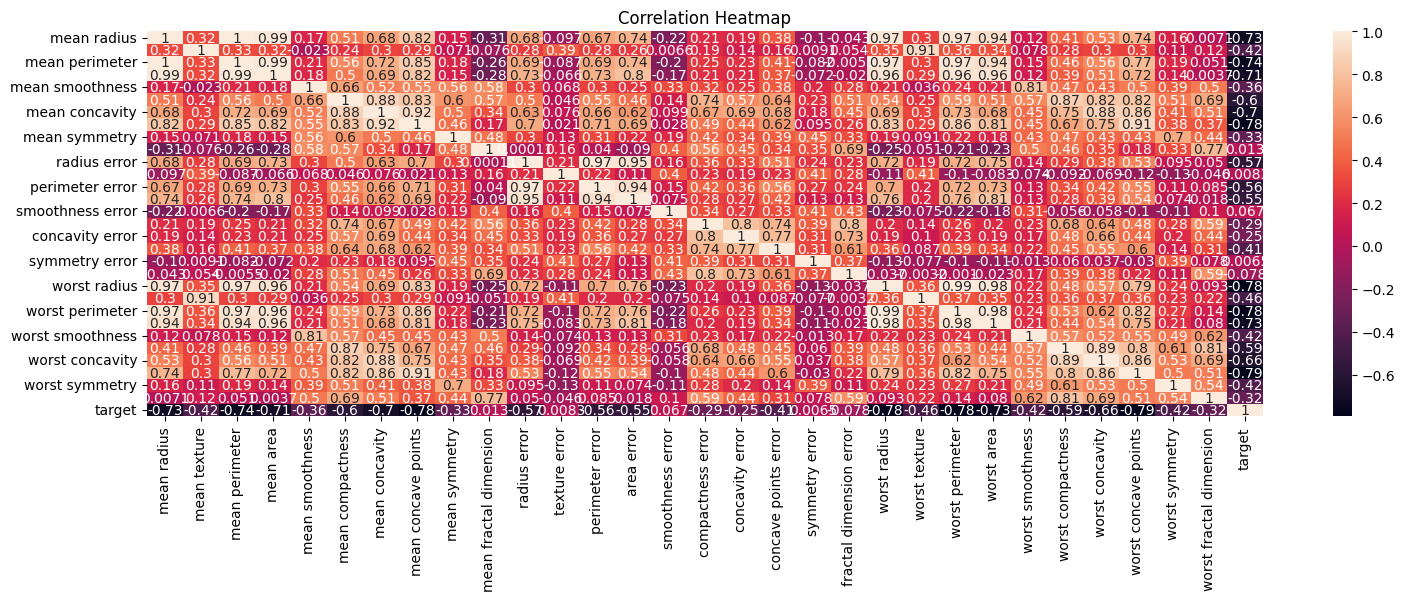

In [11]:
#### get the graphical representation for correlation between all the numerical column in the dataset

plt.figure(figsize=(18,5))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts the Correlation Heatmap.

2.  It explains about the correlation between each numerical column with respect to the other in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [12]:
#### To check for the NULL Values in the dataset

df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [13]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into independent and dependent features

In [14]:
#### independent features

X = df.drop(columns='target',axis=1)

print(X)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [15]:
#### dependent features

Y = df['target']

print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64


#### Step 6: Divide the independent and dependent features into training and testing data

In [16]:
from sklearn.model_selection import train_test_split

X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [17]:
X_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,10.32,16.35,65.31,324.9,0.09434,0.04994,0.01012,0.005495,0.1885,0.06201,...,11.25,21.77,71.12,384.9,0.1285,0.08842,0.04384,0.02381,0.2681,0.07399
432,20.18,19.54,133.80,1250.0,0.11330,0.14890,0.21330,0.125900,0.1724,0.06053,...,22.03,25.07,146.00,1479.0,0.1665,0.29420,0.53080,0.21730,0.3032,0.08075
174,10.66,15.15,67.49,349.6,0.08792,0.04302,0.00000,0.000000,0.1928,0.05975,...,11.54,19.20,73.20,408.3,0.1076,0.06791,0.00000,0.00000,0.2710,0.06164
221,13.56,13.90,88.59,561.3,0.10510,0.11920,0.07860,0.044510,0.1962,0.06303,...,14.98,17.13,101.10,686.6,0.1376,0.26980,0.25770,0.09090,0.3065,0.08177
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.02399,0.021730,0.2013,0.05955,...,12.36,26.14,79.29,459.3,0.1118,0.09708,0.07529,0.06203,0.3267,0.06994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,15.28,22.41,98.92,710.6,0.09057,0.10520,0.05375,0.032630,0.1727,0.06317,...,17.80,28.03,113.80,973.1,0.1301,0.32990,0.36300,0.12260,0.3175,0.09772
300,19.53,18.90,129.50,1217.0,0.11500,0.16420,0.21970,0.106200,0.1792,0.06552,...,25.93,26.24,171.10,2053.0,0.1495,0.41160,0.61210,0.19800,0.2968,0.09929
509,15.46,23.95,103.80,731.3,0.11830,0.18700,0.20300,0.085200,0.1807,0.07083,...,17.11,36.33,117.70,909.4,0.1732,0.49670,0.59110,0.21630,0.3013,0.10670
230,17.05,19.08,113.40,895.0,0.11410,0.15720,0.19100,0.109000,0.2131,0.06325,...,19.59,24.89,133.50,1189.0,0.1703,0.39340,0.50180,0.25430,0.3109,0.09061


In [18]:
X_test

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
256,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,25.05,36.27,178.60,1926.0,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,16.01,32.94,106.00,788.0,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,18.13,25.45,117.20,1009.0,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.45,26.40,166.10,2027.0,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20.26,23.03,132.40,1264.0,0.09078,0.13130,0.14650,0.08683,0.2095,0.05649,...,24.22,31.59,156.10,1750.0,0.1190,0.35390,0.4098,0.15730,0.3689,0.08368
128,15.10,16.39,99.58,674.5,0.11500,0.18070,0.11380,0.08534,0.2001,0.06467,...,16.11,18.33,105.90,762.6,0.1386,0.28830,0.1960,0.14230,0.2590,0.07779
257,15.32,17.27,103.20,713.3,0.13350,0.22840,0.24480,0.12420,0.2398,0.07596,...,17.73,22.66,119.80,928.8,0.1765,0.45030,0.4429,0.22290,0.3258,0.11910
228,12.62,23.97,81.35,496.4,0.07903,0.07529,0.05438,0.02036,0.1514,0.06019,...,14.20,31.31,90.67,624.0,0.1227,0.34540,0.3911,0.11800,0.2826,0.09585


In [19]:
print("Shape of the input training data is:",X_train.shape)
print("Shape of the input testing  data is:",X_test.shape)

Shape of the input training data is: (455, 30)
Shape of the input testing  data is: (114, 30)


In [20]:
Y_train

546    1
432    0
174    1
221    1
289    1
      ..
184    0
300    0
509    0
230    0
474    1
Name: target, Length: 455, dtype: int64

In [21]:
Y_test

256    0
428    1
501    0
363    1
564    0
      ..
95     0
128    1
257    0
228    1
488    1
Name: target, Length: 114, dtype: int64

In [22]:
print("Shape of the output training data is:",Y_train.shape)
print("Shape of the output testing  data is:",Y_test.shape)

Shape of the output training data is: (455,)
Shape of the output testing  data is: (114,)


#### Step 7: Perform Feature Scaling on the inputs

In [23]:
from  sklearn.preprocessing import  StandardScaler

#### Create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

In [24]:
X_train_scaled

array([[-1.07200079, -0.6584246 , -1.0880801 , ..., -1.35052668,
        -0.35265805, -0.54138003],
       [ 1.74874285,  0.06650173,  1.75115682, ...,  1.54991557,
         0.19107787, -0.1737386 ],
       [-0.97473376, -0.93112416, -0.99770871, ..., -1.70744192,
        -0.307734  , -1.21303263],
       ...,
       [ 0.39844772,  1.06867262,  0.50751384, ...,  1.53492543,
         0.16164487,  1.23754763],
       [ 0.85331409, -0.0380331 ,  0.9054796 , ...,  2.10455077,
         0.31035897,  0.36249578],
       [-0.91179628, -0.82431683, -0.87666079, ..., -0.51332734,
        -0.50756857,  1.30824791]])

In [25]:
X_test_scaled = sc.transform(X_test)

In [26]:
X_test_scaled

array([[ 1.56851278,  2.16401585,  1.74286587, ...,  1.20214432,
        -0.14043064,  0.90036171],
       [-0.84027641, -0.5970672 , -0.8741735 , ..., -1.10124064,
        -0.81429139, -0.71323608],
       [-0.07072262,  1.19138742,  0.03202768, ...,  0.57255843,
         1.14997397,  1.86841162],
       ...,
       [ 0.3583966 , -0.44935493,  0.48264098, ...,  1.63386036,
         0.54117564,  1.91191948],
       [-0.41401799,  1.07321761, -0.42314565, ...,  0.06139464,
        -0.1280378 ,  0.64747227],
       [-0.6829327 , -0.69932953, -0.66607058, ..., -0.23615965,
        -0.16211811, -0.20147486]])

#### OBSERVATIONS:

1.  All the input features have been transformed in the same scale range between -1 to 1.

#### Step 8: Train the Logistic Regression  Model

In [27]:
from sklearn.linear_model   import  LogisticRegression

#### create an object for LogisticRegression

log = LogisticRegression(max_iter=1000)

#### using the object for Logistic Regression, train the model

log.fit(X_train_scaled, Y_train)

LogisticRegression(max_iter=1000)

#### OBSERVATIONS:

1.  The object for Logistic Regression has been initialized.

2.  The Logistic Regression model has been trained with the help of the training data.

#### Step 9: Predict the model

In [28]:
Y_pred = log.predict(X_test_scaled)

In [29]:
Y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

#### Step 10: Evaluate the Clasification Metrics

In [30]:
from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0

print("Accuracy score of the model is:", ac)



print("===============================Confusion matrix=======================================================")

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion matrix of the model is:", cm)



print("===============================Classification report=======================================================")

cr = classification_report(Y_test, Y_pred)

print("Classification report of the model is:", cr)



print("===============================Precision score=======================================================")


pr = precision_score(Y_test, Y_pred)

print("Precision Score of the model is:", pr)


print("===============================Recall score=======================================================")


re = recall_score(Y_test, Y_pred)

print("Recall Score of the model is:", re)

===============================Accuracy score=======================================================
Accuracy score of the model is: 98.24561403508771
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[41  1]
 [ 1 71]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

===============================Precision score=======================================================
Precision Score of the model is: 0.9861111111111112
===============================Recall score======================

#### OBSERVATIONS:

1.  The accuracy for the Logistic Regression using breast cancer tumor data is 98.24 which is very high. The model is working fine.

2.  But the accuracy can be further be improved using hyper parameter using GridSearchCV.

#### Step 11: Predict the type of cancer based on the sample data

In [31]:
df.iloc[[395]]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
395,14.06,17.18,89.75,609.1,0.08045,0.05361,0.02681,0.03251,0.1641,0.05764,...,25.34,96.42,684.5,0.1066,0.1231,0.0846,0.07911,0.2523,0.06609,1


In [32]:
X.iloc[[395]]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
395,14.06,17.18,89.75,609.1,0.08045,0.05361,0.02681,0.03251,0.1641,0.05764,...,14.92,25.34,96.42,684.5,0.1066,0.1231,0.0846,0.07911,0.2523,0.06609


In [33]:
#### define the sample data

sample = X.iloc[[395]]

print(sample)


#### Transform the sample data

scaled_data = sc.transform(sample)

print(scaled_data)

#### perform the predictions based on the sample data

prediction = log.predict(scaled_data)

print(prediction)

if(prediction[0] == 1):
    print("Malignant(Cancerous) breast cancer tumor")
else:
    print("Benign (Non Cancerous) breast cancer tumor")

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
395        14.06         17.18           89.75      609.1          0.08045   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
395           0.05361         0.02681              0.03251         0.1641   

     mean fractal dimension  ...  worst radius  worst texture  \
395                 0.05764  ...         14.92          25.34   

     worst perimeter  worst area  worst smoothness  worst compactness  \
395            96.42       684.5            0.1066             0.1231   

     worst concavity  worst concave points  worst symmetry  \
395           0.0846               0.07911          0.2523   

     worst fractal dimension  
395                  0.06609  

[1 rows x 30 columns]
[[-0.00206354 -0.4698074  -0.07492562 -0.11446625 -1.16919775 -0.94007211
  -0.76396725 -0.40723346 -0.58901335 -0.7242881  -0.92913427  0.81673735
  -0.80431509 -0.6369962  -0.54684171 -0.69433387 -0

#### Step 12: Perform Hyper Parameter Tuning with GridSearchCV

In [34]:
#### define the pipeline

from sklearn.pipeline   import  Pipeline

#### create an object for pipeline
pipeline    =   Pipeline([
    ("sc"   ,   StandardScaler())           ,
    ("log"  ,   LogisticRegression())
])

In [35]:
#### define the param grid

param_grid = {
    "log__C"        :   [0.01,  0.1,    1,  10, 100]        ,
    "log__penalty"  :   ["l1","l2"]                         ,
    "log__solver"   :   ["lbgs" ,   "liblinear"]    
}

#### OBSERVATIONS:

1.  C ====================>  Regularization Strength

    (a.)    lower the value of C, stronger is the regularization and simpler is the model

    (b.)    higher the value of C, weaker is   the regularization and complex is the model

2. penalty ================> It determines the type of regularization used.

    (a.)  l1 ============> It prevents overfitting

    (b.)  l2 ============> It performs the feature selection

3.  solver ================> It detremines the type of optimization algorithm used to solve the problem.

In [36]:
#### perform the Stratified K Fold Cross Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
#### create the object for GridSearchCV

grid = GridSearchCV(
    pipeline                                    ,
    param_grid          =           param_grid  ,
    cv                  =              cv       ,
    scoring             =           'accuracy'  ,
    n_jobs              =              -1
)

In [38]:
#### using the object for GridSearchCV, train the model

grid.fit(X_train, Y_train)

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\pipeline.py", 

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('log', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'log__C': [0.01, 0.1, 1, 10, 100],
                         'log__penalty': ['l1', 'l2'],
                         'log__solver': ['lbgs', 'liblinear']},
             scoring='accuracy')

In [39]:
#### Obtain the best parameters and the estimator for the model

best_parameter = grid.best_params_

print("Best Parameter for the model is:", best_parameter)


best_estimator = grid.best_estimator_

print("Best Estimator for the model is:", best_estimator)

Best Parameter for the model is: {'log__C': 0.1, 'log__penalty': 'l2', 'log__solver': 'liblinear'}
Best Estimator for the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('log', LogisticRegression(C=0.1, solver='liblinear'))])


In [40]:
#### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [41]:
Y_pred_grid

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [42]:
#### Evaluate the Classification Metrics

from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)


print("===============================Precision Score=======================================================")

prgrid = precision_score(Y_test, Y_pred_grid)

print("Precision score of the model is:", prgrid)


print("===============================Recall Score=======================================================")

regrid = recall_score(Y_test, Y_pred_grid)

print("Recall score of the model is:", regrid)

===============================Accuracy score=======================================================
Accuracy score of the model is: 98.24561403508771
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[41  1]
 [ 1 71]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

===============================Precision Score=======================================================
Precision score of the model is: 0.9861111111111112
===============================Recall Score======================

#### OBSERVATIONS:

1.  The accuracy of the Logistic Regression model using breast cancer tumor data is 98.24 and remains the same even ater performing the hyper parameter tuning with GridSearchCV.

2.  The accuracy of the model remains the same.

#### Step 13: Predict whether the breast cancer tumor data is malignant or benign based on the sample data

In [43]:
#### define the sample data

sample = X.iloc[[395]]

print(sample)

#### perform the predictions based on the sample data

prediction = best_estimator.predict(sample)

print(prediction)

if(prediction[0] == 1):
    print("Malignant(Cancerous) breast cancer tumor")
else:
    print("Benign (Non Cancerous) breast cancer tumor")

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
395        14.06         17.18           89.75      609.1          0.08045   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
395           0.05361         0.02681              0.03251         0.1641   

     mean fractal dimension  ...  worst radius  worst texture  \
395                 0.05764  ...         14.92          25.34   

     worst perimeter  worst area  worst smoothness  worst compactness  \
395            96.42       684.5            0.1066             0.1231   

     worst concavity  worst concave points  worst symmetry  \
395           0.0846               0.07911          0.2523   

     worst fractal dimension  
395                  0.06609  

[1 rows x 30 columns]
[1]
Malignant(Cancerous) breast cancer tumor


#### OBSERVATIONS:

1.  Based on the sample data provided , the breast cancer tumor data is malignant

2.  This sample data was malignant before performing the Hyper Parameter Tuning with GridSearchCV operation

3.  The result is the same even ater performing the Hyper Parameter Tuning with GridSearchCV operation

4.  So the result is accurate.